# Quiz 3

This is an individual assignment.

---

Write your answers using markdown cells or embed handwritten answers with ```IPython.display.Image```.

---

**Consider the following dataset**

| x1| x2| t |
|---|---|---|
| 1 | 0 | 1 |
| 4 | 2 | 1 |
| 0 | -1| -1|
| -1| -1| -1|
| -2| 1 | -1|

**where $t$ is the ground truth target label. Answer the following questions:**

## Exercise 1 (3 points)
**Consider the _Fisher's LDA classifier_ and answer the following sub-parts:**
1. (1.5 points) **Compute the between-class scatter matrix, $S_B$, and the within-class scatter matrix, $S_W$.**
2. (1.5 points) **Find $w$ and $w_0$. Draw the respective discriminant function.**

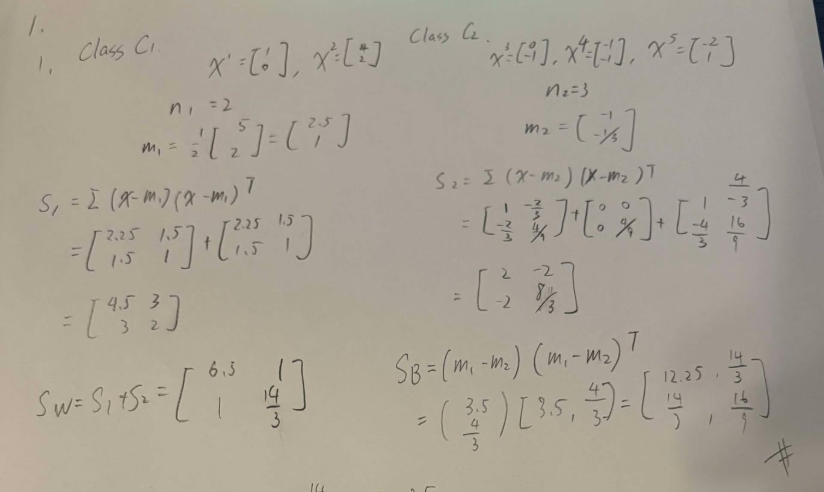

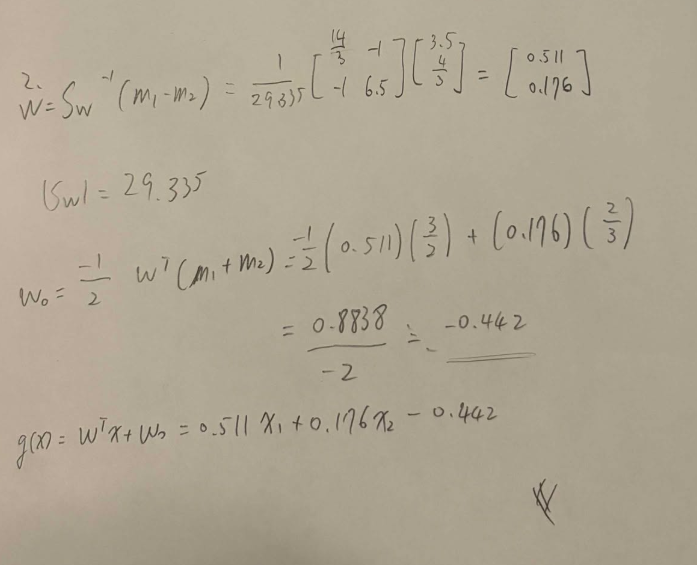

## Exercise 2 (3 points)
**Consider the Perceptron classifier with the initial weights $w=[4,1]$ and intercept $w_0=2$. Answer the following sub-parts:**
1. (1.5 points) **Draw the samples and the corresponding discriminant function.**
2. (1.5 points) **What is the smallest value for the learning rate $\eta$ such that the updated Perceptron will result in zero misclassified points using only one iteration?**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([[1, 0], [4, 2], [0, -1], [-1, -1], [-2, 1]])
t = np.array([1, 1, -1, -1, -1])

# Initial parameters for Perceptron
w = np.array([4, 1])
w0 = 2

# Part 1: Draw samples and discriminant function
plt.figure(figsize=(10, 6))

# Plot positive samples (t=1)
plt.scatter(X[t==1, 0], X[t==1, 1], c='blue', marker='o', s=100, label='t=1')
# Plot negative samples (t=-1)
plt.scatter(X[t==-1, 0], X[t==-1, 1], c='red', marker='s', s=100, label='t=-1')

# Draw discriminant function: 4*x1 + x2 + 2 = 0
# x2 = -4*x1 - 2
x1_range = np.linspace(-3, 5, 100)
x2_line = -4 * x1_range - 2

plt.plot(x1_range, x2_line, 'g-', linewidth=2, label='Initial: 4x₁ + x₂ + 2 = 0')

plt.xlabel('x₁', fontsize=12)
plt.ylabel('x₂', fontsize=12)
plt.title('Exercise 2.1: Perceptron - Samples and Initial Discriminant Function', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(-3, 5)
plt.ylim(-3, 4)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)

# Annotate points
for i, (x1, x2) in enumerate(X):
    plt.annotate(f'({x1},{x2})', (x1, x2), xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

# Check which points are misclassified
print("Exercise 2.1: Classification Results")
print("="*50)
for i, (x, label) in enumerate(zip(X, t)):
    y = np.dot(w, x) + w0
    prediction = 1 if y > 0 else -1
    status = "✓" if prediction == label else "✗"
    print(f"Point {i+1}: x={x}, y={y:.1f}, predicted={prediction:2d}, actual={label:2d} {status}")

In [ ]:
# Exercise 2.2: Find smallest learning rate η for one iteration

# Perceptron update rule:
# For misclassified point x with true label t:
# w_new = w_old + η * t * x
# w0_new = w0_old + η * t

# From previous analysis, only point (0, -1) with t=-1 is misclassified
misclassified_idx = 2  # Point (0, -1)
x_mis = X[misclassified_idx]
t_mis = t[misclassified_idx]

print("Exercise 2.2: Finding Minimum Learning Rate η")
print("="*50)
print(f"Misclassified point: x={x_mis}, t={t_mis}")
print(f"\nInitial parameters: w={w}, w0={w0}")
print(f"\nPerceptron update for misclassified point:")
print(f"w_new = w + η * t * x = {w} + η * {t_mis} * {x_mis}")
print(f"w_new = [{w[0]}, {w[1]} + η]")
print(f"w0_new = {w0} + η * {t_mis} = {w0} - η")

print(f"\n{'Point':<15} {'Constraint':<30} {'Condition':<20}")
print("-"*65)

# After update: w = [4, 1+η], w0 = 2-η
# Check all points for correct classification

constraints = []

for i, (x, label) in enumerate(zip(X, t)):
    # Calculate y = w_new^T * x + w0_new
    # w_new = [4, 1+η], w0_new = 2-η
    # y = 4*x[0] + (1+η)*x[1] + (2-η)

    coef_const = 4*x[0] + x[1] + 2  # constant term
    coef_eta = x[1] - 1  # coefficient of η

    if label == 1:
        # Need y > 0
        constraint = f"{coef_const} + {coef_eta}η > 0"
        if coef_eta > 0:
            condition = f"η > {-coef_const/coef_eta:.2f}"
            constraints.append((-coef_const/coef_eta, '>'))
        elif coef_eta < 0:
            condition = f"η < {-coef_const/coef_eta:.2f}"
            constraints.append((-coef_const/coef_eta, '<'))
        else:
            condition = "Always satisfied" if coef_const > 0 else "Never satisfied"
    else:
        # Need y < 0
        constraint = f"{coef_const} + {coef_eta}η < 0"
        if coef_eta > 0:
            condition = f"η < {-coef_const/coef_eta:.2f}"
            constraints.append((-coef_const/coef_eta, '<'))
        elif coef_eta < 0:
            condition = f"η > {-coef_const/coef_eta:.2f}"
            constraints.append((-coef_const/coef_eta, '>'))
        else:
            condition = "Always satisfied" if coef_const < 0 else "Never satisfied"

    print(f"{str(x):<15} {constraint:<30} {condition:<20}")

# Find the minimum η that satisfies all constraints
print("\n" + "="*65)
print("Analysis:")
print("- From point (1, 0): 6 - η > 0  =>  η < 6")
print("- From point (4, 2): 20 + η > 0  =>  always satisfied")
print("- From point (0, -1): 1 - 2η < 0  =>  η > 0.5")
print("- From point (-1, -1): -3 - 2η < 0  =>  always satisfied")
print("- From point (-2, 1): -5 < 0  =>  always satisfied")

print("\nCombining constraints: 0.5 < η < 6")
print("\n" + "="*65)
print(f"✓ Minimum learning rate η = 0.5")
print("="*65)

# Verify with η = 0.5
eta_min = 0.5
w_new = w + eta_min * t_mis * x_mis
w0_new = w0 + eta_min * t_mis

print(f"\nVerification with η = {eta_min}:")
print(f"Updated parameters: w={w_new}, w0={w0_new}")
print(f"\nClassification after update:")
for i, (x, label) in enumerate(zip(X, t)):
    y = np.dot(w_new, x) + w0_new
    prediction = 1 if y > 0 else -1
    status = "✓" if prediction == label else "✗"
    print(f"Point {i+1}: x={x}, y={y:.1f}, predicted={prediction:2d}, actual={label:2d} {status}")

## Exercise 3 (3 points)
**Consider the Logistic Regression classifier with the initial weights $w=[4,1]$ and intercept $w_0=2$. Let a label $t=-1$ be mapped to $t=0$. Answer the following sub-parts:**
1. (1.5 points) **Use the initial parameter values to predict the label for each samples above.**
2. (1.5 points) **What is the smallest value for the learning rate $\eta$ such that the updated Logistic Regression will result in zero misclassified points using only one iteration?**

In [ ]:
# Exercise 3.1: Logistic Regression - Predict labels

# Map t=-1 to t=0 for Logistic Regression
t_lr = np.where(t == -1, 0, 1)

# Initial parameters (same as Perceptron)
w_lr = np.array([4, 1])
w0_lr = 2

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("Exercise 3.1: Logistic Regression - Label Prediction")
print("="*70)
print(f"Initial parameters: w={w_lr}, w0={w0_lr}")
print(f"\nLogistic Regression prediction: p = sigmoid(w^T x + w0)")
print(f"Decision rule: if p ≥ 0.5, predict 1; else predict 0")
print("\n" + "="*70)
print(f"{'Point':<12} {'x':<12} {'z=w^Tx+w0':<12} {'p=σ(z)':<12} {'Predicted':<12} {'Actual':<10} {'Status'}")
print("-"*70)

predictions = []
probabilities = []

for i, (x, label) in enumerate(zip(X, t_lr)):
    z = np.dot(w_lr, x) + w0_lr
    p = sigmoid(z)
    prediction = 1 if p >= 0.5 else 0
    predictions.append(prediction)
    probabilities.append(p)
    status = "✓" if prediction == label else "✗"
    print(f"Point {i+1:<6} {str(x):<12} {z:<12.1f} {p:<12.4f} {prediction:<12d} {label:<10d} {status}")

predictions = np.array(predictions)
probabilities = np.array(probabilities)

print("="*70)
print(f"\nMisclassified points: {np.sum(predictions != t_lr)} out of {len(t_lr)}")
misclassified_indices = np.where(predictions != t_lr)[0]
if len(misclassified_indices) > 0:
    print(f"Misclassified: Point(s) {[i+1 for i in misclassified_indices]}")
print("="*70)

In [ ]:
# Exercise 3.2: Find smallest learning rate η for Logistic Regression

print("\nExercise 3.2: Finding Minimum Learning Rate η")
print("="*70)
print("Gradient Descent update rule:")
print("w_new = w - η * ∇w")
print("w0_new = w0 - η * ∇w0")
print("\nwhere:")
print("∇w = Σ(p_i - t_i) * x_i")
print("∇w0 = Σ(p_i - t_i)")
print("\n" + "="*70)

# Calculate gradients
grad_w = np.zeros(2)
grad_w0 = 0

print(f"{'Point':<10} {'x':<12} {'p_i':<10} {'t_i':<6} {'p_i - t_i':<12} {'(p_i-t_i)*x'}")
print("-"*70)

for i, (x, label) in enumerate(zip(X, t_lr)):
    z = np.dot(w_lr, x) + w0_lr
    p = sigmoid(z)
    error = p - label
    grad_w += error * x
    grad_w0 += error
    print(f"Point {i+1:<5} {str(x):<12} {p:<10.4f} {label:<6d} {error:<12.4f} {error * x}")

print("-"*70)
print(f"Gradients: ∇w = {grad_w}, ∇w0 = {grad_w0:.4f}")
print("="*70)

# Search for minimum η
# We need to find η such that after one update, all points are correctly classified
# w_new = w - η * grad_w
# w0_new = w0 - η * grad_w0

# For correct classification:
# For label 1: sigmoid(w_new^T x + w0_new) ≥ 0.5  =>  w_new^T x + w0_new ≥ 0
# For label 0: sigmoid(w_new^T x + w0_new) < 0.5  =>  w_new^T x + w0_new < 0

print("\nSearching for minimum η...")

# Test different values of η
eta_values = np.linspace(0.01, 10, 10000)
min_eta = None

for eta in eta_values:
    w_new = w_lr - eta * grad_w
    w0_new = w0_lr - eta * grad_w0

    # Check if all points are correctly classified
    all_correct = True
    for x, label in zip(X, t_lr):
        z = np.dot(w_new, x) + w0_new
        prediction = 1 if z >= 0 else 0
        if prediction != label:
            all_correct = False
            break

    if all_correct:
        min_eta = eta
        break

if min_eta is not None:
    print(f"\n✓ Minimum learning rate η ≈ {min_eta:.4f}")
    print("="*70)

    # Verify
    w_final = w_lr - min_eta * grad_w
    w0_final = w0_lr - min_eta * grad_w0

    print(f"\nVerification with η = {min_eta:.4f}:")
    print(f"Updated parameters: w={w_final}, w0={w0_final:.4f}")
    print(f"\nClassification after update:")
    print(f"{'Point':<10} {'x':<12} {'z':<12} {'p=σ(z)':<12} {'Predicted':<12} {'Actual':<10} {'Status'}")
    print("-"*70)

    for i, (x, label) in enumerate(zip(X, t_lr)):
        z = np.dot(w_final, x) + w0_final
        p = sigmoid(z)
        prediction = 1 if p >= 0.5 else 0
        status = "✓" if prediction == label else "✗"
        print(f"Point {i+1:<5} {str(x):<12} {z:<12.4f} {p:<12.4f} {prediction:<12d} {label:<10d} {status}")

    print("="*70)
else:
    print("\nNo valid η found in the search range.")
    print("The problem might not be linearly separable or requires a larger η.")
    print("="*70)

In [ ]:
# Visualization: Compare initial and updated decision boundaries

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Initial boundary
ax1 = axes[0]
ax1.scatter(X[t_lr==1, 0], X[t_lr==1, 1], c='blue', marker='o', s=100, label='t=1')
ax1.scatter(X[t_lr==0, 0], X[t_lr==0, 1], c='red', marker='s', s=100, label='t=0')

x1_range = np.linspace(-3, 5, 100)
x2_initial = (-w0_lr - w_lr[0] * x1_range) / w_lr[1]
ax1.plot(x1_range, x2_initial, 'g-', linewidth=2, label='Initial: 4x₁ + x₂ + 2 = 0')

ax1.set_xlabel('x₁', fontsize=12)
ax1.set_ylabel('x₂', fontsize=12)
ax1.set_title('Exercise 3: Initial Decision Boundary', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xlim(-3, 5)
ax1.set_ylim(-3, 4)
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)

for i, (x1, x2) in enumerate(X):
    ax1.annotate(f'({x1},{x2})', (x1, x2), xytext=(5, 5), textcoords='offset points', fontsize=9)

# Right plot: Updated boundary (if min_eta was found)
ax2 = axes[1]
ax2.scatter(X[t_lr==1, 0], X[t_lr==1, 1], c='blue', marker='o', s=100, label='t=1')
ax2.scatter(X[t_lr==0, 0], X[t_lr==0, 1], c='red', marker='s', s=100, label='t=0')

ax2.plot(x1_range, x2_initial, 'g--', linewidth=1.5, alpha=0.5, label='Initial boundary')

if min_eta is not None:
    w_final = w_lr - min_eta * grad_w
    w0_final = w0_lr - min_eta * grad_w0
    x2_final = (-w0_final - w_final[0] * x1_range) / w_final[1]
    ax2.plot(x1_range, x2_final, 'purple', linewidth=2,
             label=f'Updated (η={min_eta:.4f})')

ax2.set_xlabel('x₁', fontsize=12)
ax2.set_ylabel('x₂', fontsize=12)
ax2.set_title('Exercise 3: Updated Decision Boundary', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xlim(-3, 5)
ax2.set_ylim(-3, 4)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)

for i, (x1, x2) in enumerate(X):
    ax2.annotate(f'({x1},{x2})', (x1, x2), xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

---

# On-Time + Notebook PDF (1 point)

Submit your assignment as a PDF file before the deadline.

___

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

___